In [1]:
# autoreload packages
%load_ext autoreload
%autoreload 2

In [2]:
# ==== Imports ====
import os, random, numpy as np, torch

# pymoo components
from mergenetic.merging.taskarithmetic_merger import TaskArithmeticMerger

# Mergekit and Mergenetic
import mergekit
import mergenetic
from mergenetic.searcher import Searcher
from mergenetic.utils import ConfigLmEval
from mergenetic import PROJECT_ROOT
from mergenetic.optimization.predefined_problems import (MathReasoningProblem, ConfigPE) 

# lm_eval
from lm_eval.tasks import TaskManager

# Hugging Face 
from huggingface_hub import whoami
from huggingface_hub import notebook_login
from huggingface_hub import snapshot_download


PROJECT_ROOT IS HARCODED AT /mnt/ssd1/adrian/projects/merging-for-reasoning


In [3]:
# ==== Set the seeds ====
SEED = 0

# Python
random.seed(SEED)
# NumPy
np.random.seed(SEED)
# PyTorch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Environment variables
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"All seeds set to {SEED}")

All seeds set to 0


In [4]:
# directory where to store base and merged models
model_dir = "/mnt/ssd2/models"
os.makedirs(model_dir, exist_ok=True)

# DeepSeek-R1-Distill-Qwen-7B (Base model)
deepseek_repo = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
snapshot_download(
    repo_id=deepseek_repo,
    local_dir=os.path.join(model_dir, "DeepSeek-R1-Distill-Qwen-7B")
)

# Qwen2.5-Math-7B (Target model)
qwen_math_repo = "Qwen/Qwen2.5-Math-7B"
snapshot_download(
    repo_id=qwen_math_repo,
    local_dir=os.path.join(model_dir, "Qwen2.5-Math-7B")
)

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

'/mnt/ssd2/models/Qwen2.5-Math-7B'

In [5]:
config = ConfigLmEval()

# Set the absolute path for custom templates
config.additional_templates_folder = os.path.join(PROJECT_ROOT, "mergenetic", "lm_tasks")
config.bench = "gsm8k"
config.path_to_store_config = os.path.join(PROJECT_ROOT, "mergenetic", "experiments", "spearman-ranking", "configs")

# Reproducibility
config.seed = SEED  

# Device for evaluation ("cuda" if available, else "cpu")
config.device = "cuda"  

# Run identifier (used for logs, checkpoints, results)
config.run_id = "Mergenetic-TA"  

# Metric to evaluate correctness
config.metric = "exact_match"  

# Task type (here: focused on math reasoning, e.g. GSM8K)
config.task_type = "FG_MATH"  

# Paths for saving configs, logs, and merged models
config.path_to_store_merged_model = f"{model_dir}/merged"

# Non-canonical setup:
#   - Deepseek-R1-Distill-Qwen → distillation of DeepSeek-R1 into a Qwen architecture
#   - Qwen2.5-Math-7B        → fine-tuned Qwen2.5 on math reasoning
config.base_model = f"{model_dir}/DeepSeek-R1-Distill-Qwen-7B"
config.models = {"en": f"{model_dir}/Qwen2.5-Math-7B"}

# Fitness evaluation mode ("mean" = average across anchors)
config.mode = "mean"  

# Languages involved (English only in this case)
config.langs = ["en"]  

# Batch size for evaluation
config.eval_batch_size = 8  

In [6]:
config

ConfigLmEval(pop_size=None, n_iter=None, path_to_store_config='/mnt/ssd1/adrian/projects/merging-for-reasoning/mergenetic/experiments/spearman-ranking/configs', path_to_store_merged_model='/mnt/ssd2/models/merged', datasets=None, run_id='Mergenetic-TA', bench='gsm8k', models={'en': '/mnt/ssd2/models/Qwen2.5-Math-7B'}, task_type='FG_MATH', langs=['en'], seed=0, n_samples=20, mode='mean', dtype='bfloat16', device='cuda', base_model='/mnt/ssd2/models/DeepSeek-R1-Distill-Qwen-7B', force_evaluation=False, eval_batch_size=8, metric='exact_match', tasks=None, additional_templates_folder='/mnt/ssd1/adrian/projects/merging-for-reasoning/mergenetic/lm_tasks', load_in_4bit=True, eager_mode=False)

In [7]:
path_to_store_yaml = f"{config.path_to_store_config}/{config.run_id}"
lang_id = "en"

"""
merger = TiesMerger(
    run_id=config.run_id,
    path_to_base_model=config.base_model,
    model_paths=[config.models[lang_id]],
    path_to_store_yaml=path_to_store_yaml,
    path_to_store_merged_model=config.path_to_store_merged_model,
    dtype=config.dtype,    
)
"""

merger = TaskArithmeticMerger(
    run_id=config.run_id,
    path_to_base_model=config.base_model,
    model_paths=[config.models[lang_id]],
    path_to_store_yaml=path_to_store_yaml,
    path_to_store_merged_model=config.path_to_store_merged_model,
    dtype=config.dtype,
)

print("✅ Merger configured.")

✅ Merger configured.


In [8]:
# read csv from ../evolutionary-merging-lm-harness/TA_multiobjective_7B/TA_multiobjective_objective_1.csv
import pandas as pd
genotype1_df = pd.read_csv("../evolutionary-merging-lm-harness/TA_multiobjective_7B/TA_multiobjective_7B_objective_1.csv")
genotype2_df = pd.read_csv("../evolutionary-merging-lm-harness/TA_multiobjective_7B/TA_multiobjective_7B_objective_2.csv")

In [9]:
# merge the two dataframes on 'genotype_1' and 'step' column
merged_df = pd.merge(genotype1_df, genotype2_df, on=['genotype_1', 'step'], suffixes=('_1', '_2'))

merged_df

,objective_1,genotype_1,step,objective_2
0,-0.700000,0.600000,1,512.366667
1,-0.866667,0.300000,2,747.266667
2,-0.600000,1.000000,3,216.733333
3,-0.666667,0.700000,4,216.866667
4,-0.833333,0.400000,5,730.533333
...,...,...,...,...
184,-0.733333,0.632401,185,216.700000
185,-0.900000,0.092274,186,1279.033333
186,-0.800000,0.501777,187,552.166667
187,-0.800000,0.060763,188,1397.000000


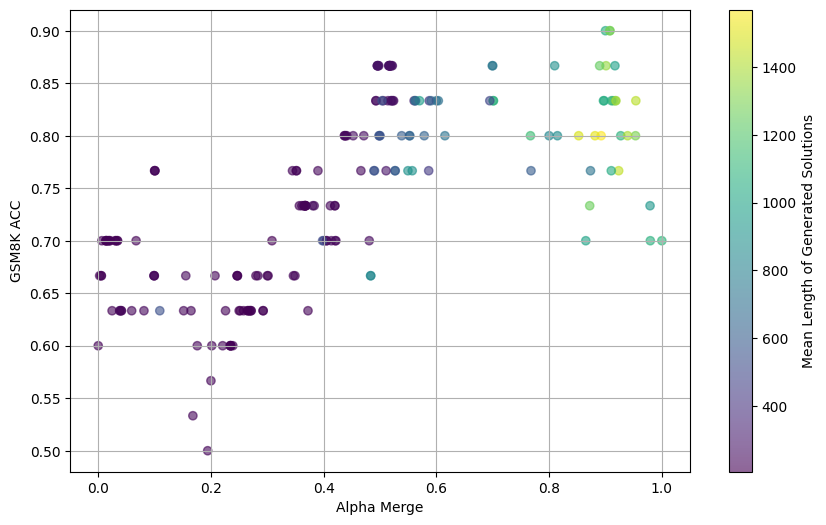

In [10]:
# plot objective_1 vs objective_2
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(1-merged_df['genotype_1'], -merged_df['objective_1'], alpha=0.6, c=merged_df['objective_2'])
plt.xlabel('Alpha Merge')
plt.ylabel('GSM8K ACC')
plt.colorbar(label='Mean Length of Generated Solutions')
plt.grid(True)
plt.show()

In [11]:
# find the top 10 rows with lowest objective_1
obj_1 = merged_df.sort_values("objective_1", ascending=True)
obj_2 = merged_df.sort_values("objective_2", ascending=True)

In [12]:
# find pareto front using numpy
O = np.array(merged_df[["objective_1", "objective_2"]])
# find pareto front using pymoo
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
nds = NonDominatedSorting()
pareto_front = nds.do(O, only_non_dominated_front=True)
pareto_df = merged_df.iloc[pareto_front]
pareto_df = pareto_df.sort_values("objective_1", ascending=True)

print("Pareto Front:")
print(pareto_df.head(10))

genotypes_1dot5B = [0.380109, 0.392871, 0.533080, 0.460484, 0.520911, 0.518455, 0.521058, 0.780129, 0.958123, 0.991416]
genotypes_7B = [0.1, 0.3, 0.35, 0.4, 0.45, 0.55, 0.6, 0.64, 0.78, 0.95]

Pareto Front:
     objective_1  genotype_1  step  objective_2
8      -0.900000    0.100000     9  1048.600000
21     -0.866667    0.481584    22   262.800000
30     -0.866667    0.482679    31   262.800000
85     -0.866667    0.482686    86   262.800000
146    -0.866667    0.482964   147   262.800000
158    -0.866667    0.482819   159   262.800000
170    -0.866667    0.481909   171   262.800000
51     -0.833333    0.494401    52   250.000000
52     -0.800000    0.558982    53   226.833333
110    -0.766667    0.648261   111   221.500000


In [13]:
import subprocess
# set environment variable to have CUDA_VISIBLE_DEVICES=2
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

genotypes = genotypes_7B # [0.0, 1.0] # just evaluate the base and target models

# for each genotype in genotypes, create a merged model and evaluate it
for index, row in enumerate(genotypes):
    genotype = [row,]
    print(f"Processing genotype {genotype} ({index+1}/{len(genotypes)})")
    
    # create a merged model
    merged_model_conf_path = merger.create_individual_configuration(genotype)
    merged_model_path = merger.merge_model_from_configuration(merged_model_conf_path)
    print(f"✅ Merged model created at {merged_model_path}")
    
    # put "CUDA_VISIBLE_DEVICES=1" into env
    subprocess.run(["python3", "../Qwen2.5-Math/evaluation/math_eval.py",
        "--model_name_or_path", f"{merged_model_path}",
        "--data_names", "gsm8k", #aime24,gsm8k,college_math,minerva_math,olympiadbench",
        "--output_dir", f"eval_results_7B/{genotype[0]}",
        "--prompt_type", "deepseek-math",
        "--n_sampling", "1",
        "--max_tokens_per_call", "10240",
        "--num_shots", "0",
        "--seed", f"{SEED}",
        "--split", "test",
        "--use_vllm",
        "--save_outputs",
        "--overwrite",
        "--data_dir", f"../Qwen2.5-Math/evaluation/data"
    ], env={**os.environ}, cwd=f"{PROJECT_ROOT}/mergenetic")

Processing genotype [0.1] (1/10)


Executing graph: 100%|██████████| 1697/1697 [00:25<00:00, 65.38it/s] 


✅ Merged model created at /mnt/ssd2/models/merged/Mergenetic-TA
Random seed set as 0
INFO 09-20 14:41:01 llm_engine.py:161] Initializing an LLM engine (v0.5.0.post1) with config: model='/mnt/ssd2/models/merged/Mergenetic-TA', speculative_config=None, tokenizer='/mnt/ssd2/models/merged/Mergenetic-TA', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, rope_scaling=None, rope_theta=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=131072, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='outlines'), seed=0, served_model_name=/mnt/ssd2/models/merged/Mergenetic-TA)
INFO 09-20 14:41:03 model_runner.py:160] Loading model weights took 14.2716 GB
INFO 09-20 14:41:19 gpu_executor.py:83] # GPU blocks: 11532, # CPU blocks: 4681


 16%|█▌        | 212/1319 [00:00<00:01, 1067.58it/s]

User: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Please reason step by step, and put your final answer within \boxed{}.

Assistant:


...

-------------------- Epoch 0


Processed prompts: 100%|██████████| 1319/1319 [05:56<00:00,  3.69it/s, est. speed input: 303.09 toks/s, output: 1390.38 toks/s]


-------------------- Epoch 1
Unsolved samples: 0


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Evaluate: 100%|██████████| 1319/1319 [00:00<00:00, 3525.29it/s]


{'num_samples': 1319, 'num_scores': 1319, 'timeout_samples': 0, 'empty_samples': 1, 'acc': np.float64(83.3)}
Saved to outputs/eval_results_7B/0.95/gsm8k/test_deepseek-math_-1_seed0_t0_s0_e-1.jsonl
gsm8k	avg  
83.3 	83.3 


In [ ]:
# !CUDA_VISIBLE_DEVICES=0 python math_eval.py \
#   --model_name_or_path deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B \
#   --data_names aime24,college_math,gsm8k,math,minerva_math,olympiadbench \
#   --output_dir DEEPSEEK-R1 \
#   --prompt_type deepseek-math \
#   --n_sampling 1 \
#   --max_tokens_per_call 10240 \
#   --num_shots 0 \
#   --seed 0 \
#   --split test \
#   --use_vllm \
#   --save_outputs \
#   --overwrite



In [16]:
# find all bench files in PROJECT_ROOT/mergenetic/outputs/eval_results/{genotype}/
import os, json, pandas as pd

BENCHMARKS = ["gsm8k"]# ["aime24", "gsm8k", "college_math", "minerva_math", "olympiadbench"]

genotypes = [0.0, 1.0] + genotypes_7B# [0.0, 0.380109, 0.392871, 0.533080, 0.460484, 0.520911, 0.518455, 0.521058	, 0.780129, 0.958123, 0.991416, 1.0]

results = [] # list of dicts with keys: genotype, benchmark, accuracy
for genotype in genotypes:
    for benchmark in BENCHMARKS:
        results_file = os.path.join(PROJECT_ROOT, "mergenetic", "outputs", "eval_results_7B", str(genotype), f"{benchmark}", "test_deepseek-math_-1_seed0_t0_s0_e-1_deepseek-math_metrics.json")
        if os.path.exists(results_file):
            with open(results_file, "r") as f:
                data = json.load(f)
                accuracy = data.get("acc", None)
                if accuracy is not None:
                    results.append({
                        "genotype": genotype,
                        "benchmark": benchmark,
                        "accuracy": accuracy
                    })
                else :
                    print(f"No accuracy found in {results_file}")
        else:
            print(f"Results file {results_file} does not exist.")

results_df = pd.DataFrame(results)

In [17]:
import json

def extract_index_and_score(file_path, bench_name, genotype):
    """
    Reads a JSONL file and extracts 'index' and 'score' from each line.
    
    Args:
        file_path (str): Path to the JSONL file.
    
    Returns:
        list: A list of dictionaries, each containing 'index' and 'score'.
              If a line does not have both keys, it is skipped.
    """
    results = []
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            #print(f"Reading file: {file_path}")
            for line in file:
                line = line.strip()
                if line:  # Skip empty lines
                    try:
                        data = json.loads(line)
                        if 'idx' in data and 'score' in data:
                            results.append({
                                'index': data['idx'],
                                'score': data['score'][0],
                                'benchmark': bench_name,
                                'genotype': genotype,
                                'answer_length': len(data['code'][0]) if 'code' in data else None
                            })
                    except json.JSONDecodeError:
                        # Skip lines that aren't valid JSON
                        print(f"Skipping invalid JSON line: {line}")
                        continue
    except FileNotFoundError:
        raise FileNotFoundError(f"The file at {file_path} was not found.")
    except Exception as e:
        raise Exception(f"An error occurred while reading the file: {str(e)}")
    
    return results

In [18]:
results_df.to_csv("genotype_benchmark_accuracies_7B.csv", index=False)

In [20]:
# now let's take a look at the correctness of each answer for each genotype
#BENCHMARKS = ["aime24", "gsm8k", "college_math", "minerva_math", "olympiadbench"]


#genotypes = [0.0, 0.380109, 0.392871, 0.533080, 0.460484, 0.520911, 0.518455, 0.521058	, 0.780129, 0.958123, 0.991416, 1.0]

results_correctness = [] # list of dicts with keys: genotype, benchmark, accuracy
for genotype in genotypes:
    for benchmark in BENCHMARKS:
        results_file = os.path.join(PROJECT_ROOT, "mergenetic", "outputs", "eval_results_7B", str(genotype), f"{benchmark}", "test_deepseek-math_-1_seed0_t0_s0_e-1.jsonl")
        correctness = extract_index_and_score(results_file, benchmark, genotype)
        print(f"Extracted {len(correctness)} correctness entries from {results_file}")
        results_correctness.extend(correctness)

Extracted 1319 correctness entries from /mnt/ssd1/adrian/projects/merging-for-reasoning/mergenetic/outputs/eval_results_7B/0.0/gsm8k/test_deepseek-math_-1_seed0_t0_s0_e-1.jsonl
Extracted 1319 correctness entries from /mnt/ssd1/adrian/projects/merging-for-reasoning/mergenetic/outputs/eval_results_7B/1.0/gsm8k/test_deepseek-math_-1_seed0_t0_s0_e-1.jsonl
Extracted 1319 correctness entries from /mnt/ssd1/adrian/projects/merging-for-reasoning/mergenetic/outputs/eval_results_7B/0.1/gsm8k/test_deepseek-math_-1_seed0_t0_s0_e-1.jsonl
Extracted 1319 correctness entries from /mnt/ssd1/adrian/projects/merging-for-reasoning/mergenetic/outputs/eval_results_7B/0.3/gsm8k/test_deepseek-math_-1_seed0_t0_s0_e-1.jsonl
Extracted 1319 correctness entries from /mnt/ssd1/adrian/projects/merging-for-reasoning/mergenetic/outputs/eval_results_7B/0.35/gsm8k/test_deepseek-math_-1_seed0_t0_s0_e-1.jsonl
Extracted 1319 correctness entries from /mnt/ssd1/adrian/projects/merging-for-reasoning/mergenetic/outputs/eval_re

In [21]:
# Let's add length as additional benchmark metric
results_correctness_df = pd.DataFrame(results_correctness)
results_correctness_df.to_csv("detailed_correctness_7B.csv", index=False)

In [22]:
# filter only gsm8k
gsm8k_results = results_correctness_df[results_correctness_df['benchmark'] == 'mean_length']
# sort by accuracy descending
gsm8k_results = gsm8k_results.sort_values("score", ascending=False)
gsm8k_results

,index,score,benchmark,genotype,answer_length
